<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812 entries, 0 to 1811
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             1812 non-null   object 
 1   open             1810 non-null   float64
 2   high             1810 non-null   float64
 3   low              1810 non-null   float64
 4   close            1810 non-null   float64
 5   adjclose         1810 non-null   float64
 6   volume           1812 non-null   int64  
 7   ingested_at_utc  1812 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 113.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812 entries, 0 to 1811
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             1812 non-null   datetime64[ns]
 1   open             1810 non-null   float64       
 2   high             1810 non-null   float64       

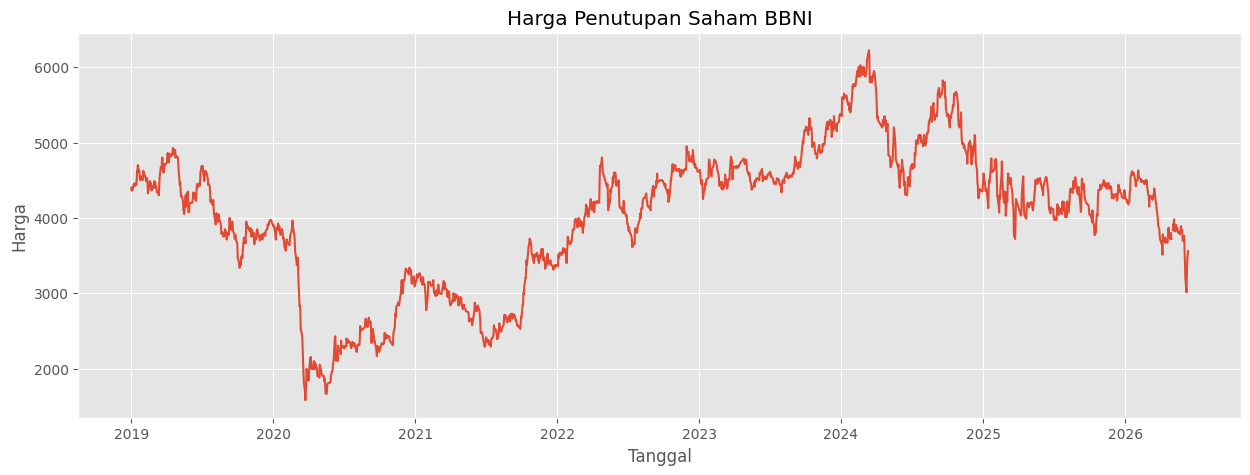

Harga Tertinggi : 6225.0
Harga Terendah : 1580.0
Harga Rata-rata : 4032.1505524861877


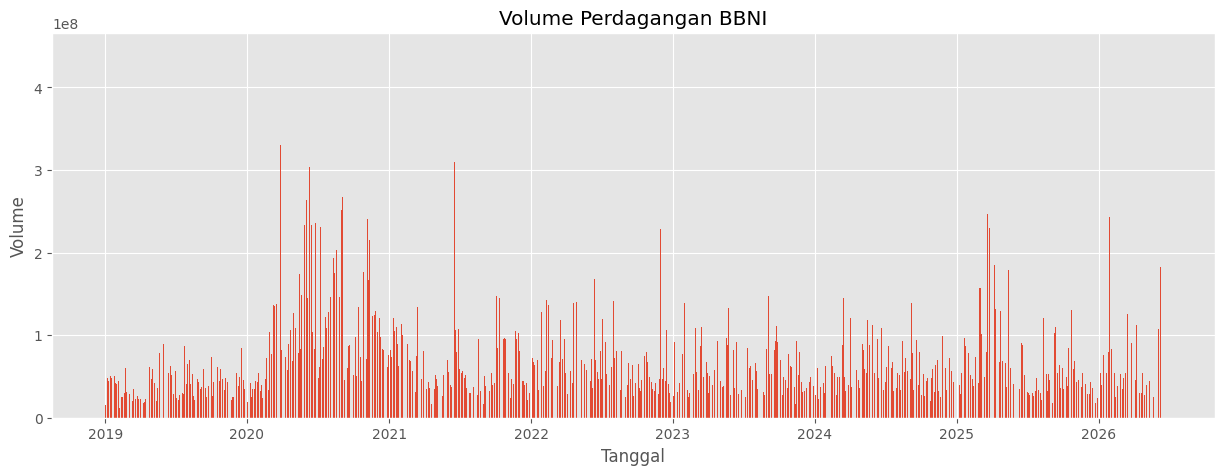

/tmp/ipykernel_3044/2731973311.py:65: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Return'] = df['close'].pct_change() * 100


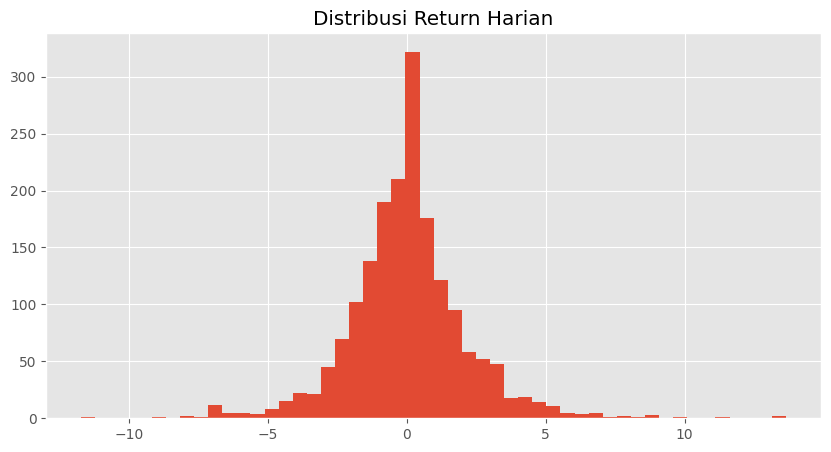

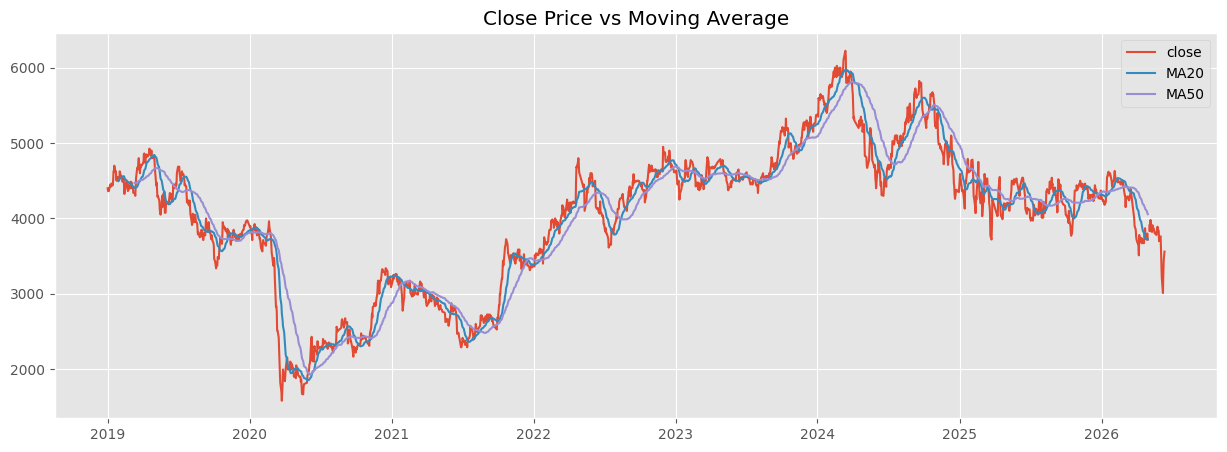

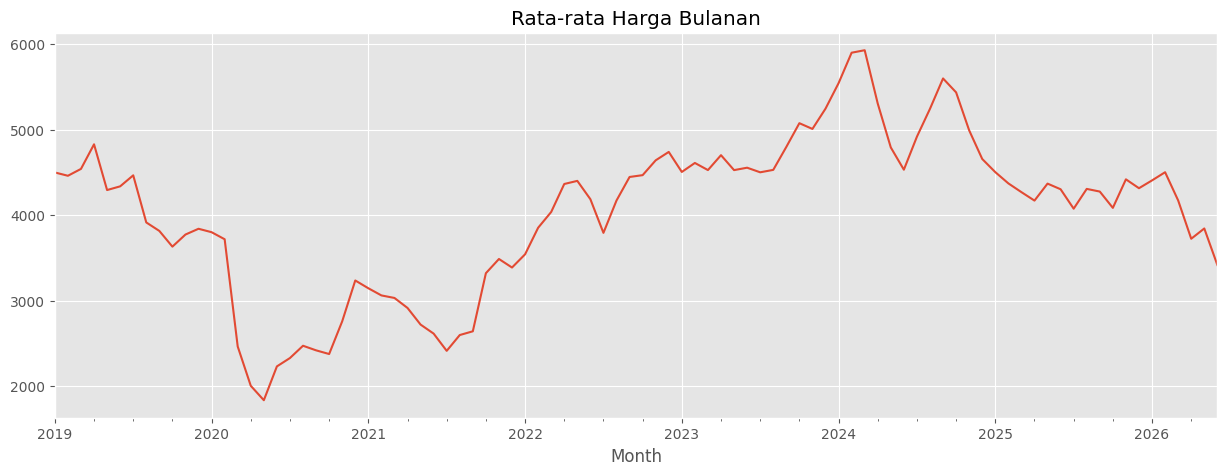

In [19]:
# Analisis Historis Saham BBNI

# Tujuan
# Menganalisis pergerakan harga saham BBNI berdasarkan data historis untuk mengetahui tren harga, volume transaksi, return, dan indikator moving average.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

# Load Dataset
# Mengimpor dataset historis saham BBNI.

df = pd.read_csv('BBNI.JK.csv')
df.head()

# Exploratory Data Analysis (EDA)
# Melihat struktur dataset dan tipe data.

df.info()
df.describe()
df.shape

# Data Cleaning
# Memeriksa missing value dan memastikan tipe data sudah sesuai.

df.isnull().sum()
df['Date'] = pd.to_datetime(df['Date'])
df.info()

# Analisis Tren Harga Saham
# Visualisasi harga penutupan saham dari waktu ke waktu.

plt.figure(figsize=(15,5))
plt.plot(df['Date'], df['close'])
plt.title('Harga Penutupan Saham BBNI')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.show()

# Statistik Harga

highest = df['close'].max()
lowest = df['close'].min()
average = df['close'].mean()

print("Harga Tertinggi :", highest)
print("Harga Terendah :", lowest)
print("Harga Rata-rata :", average)

# Analisis Volume Transaksi
# Melihat aktivitas perdagangan saham.

plt.figure(figsize=(15,5))
plt.bar(df['Date'], df['volume'])
plt.title('Volume Perdagangan BBNI')
plt.xlabel('Tanggal')
plt.ylabel('Volume')
plt.show()

# Return Harian
# Menghitung persentase perubahan harga harian.

df['Return'] = df['close'].pct_change() * 100
df[['Date','close','Return']].head()

plt.figure(figsize=(10,5))
plt.hist(df['Return'].dropna(), bins=50)
plt.title('Distribusi Return Harian')
plt.show()

# Moving Average
# Menggunakan MA20 dan MA50 untuk melihat tren harga.

df['MA20'] = df['close'].rolling(window=20).mean()
df['MA50'] = df['close'].rolling(window=50).mean()

plt.figure(figsize=(15,5))
plt.plot(df['Date'], df['close'], label='close')
plt.plot(df['Date'], df['MA20'], label='MA20')
plt.plot(df['Date'], df['MA50'], label='MA50')
plt.legend()
plt.title('Close Price vs Moving Average')
plt.show()

# Analisis Bulanan
# Melihat rata-rata harga penutupan per bulan.

df['Month'] = df['Date'].dt.to_period('M')

monthly = df.groupby('Month')['close'].mean()
monthly.plot(figsize=(15,5))

plt.title('Rata-rata Harga Bulanan')
plt.show()

# Kesimpulan

# 1. Harga saham BBNI mengalami fluktuasi selama periode pengamatan.
# 2. Terdapat beberapa periode dengan volume transaksi tinggi yang diikuti perubahan harga signifikan.
# 3. Moving Average menunjukkan arah tren jangka pendek dan menengah.
# 4. Return harian memperlihatkan tingkat volatilitas saham.